In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('../data/monthly_full_release_long_format.csv')

df

,Area,ISO 3 code,Date,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,12.77,NaN,NaN
1,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,%,34.57,NaN,NaN
2,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,%,65.44,NaN,NaN
3,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,0.0,Electricity generation,Aggregate fuel,Gas and Other Fossil,%,63.40,NaN,NaN
4,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,0.0,Electricity generation,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",%,29.08,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501478,World,NaN,2025-11-01,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Power sector emissions,Fuel,Other Fossil,mtCO2,43.57,-4.71,-9.76
501479,World,NaN,2025-11-01,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Power sector emissions,Fuel,Other Renewables,mtCO2,0.43,-0.01,-2.27
501480,World,NaN,2025-11-01,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Power sector emissions,Fuel,Solar,mtCO2,9.02,2.06,29.60
501481,World,NaN,2025-11-01,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Power sector emissions,Fuel,Wind,mtCO2,3.06,0.49,19.07


## **EDA**

In [25]:
info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print("\n--- Data Information ---")
print(info)

Total Rows: 501483
Total Columns: 18

--- Data Information ---
                    Data Type  Non-Null Count  Missing Values  Missing %
Area                      str          501483               0   0.000000
ISO 3 code                str          445688           55795  11.126000
Date                      str          501483               0   0.000000
Area type                 str          501483               0   0.000000
Continent                 str          445688           55795  11.126000
Ember region              str          445688           55795  11.126000
EU                    float64          445688           55795  11.126000
OECD                  float64          445688           55795  11.126000
G20                   float64          445688           55795  11.126000
G7                    float64          445688           55795  11.126000
ASEAN                 float64          445688           55795  11.126000
Category                  str          501483               0

In [26]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

missing_by_year = df.assign(IsMissing=df['Value'].isna()).groupby('Year')['IsMissing'].agg(['count', 'sum'])
missing_by_year.columns = ['Total Baris', 'Baris Kosong']
missing_by_year['% Kosong'] = (missing_by_year['Baris Kosong'] / missing_by_year['Total Baris']) * 100

print(missing_by_year.round(2).to_string())

      Total Baris  Baris Kosong  % Kosong
Year                                     
1998           17             5     29.41
1999          528             0      0.00
2000         1260             0      0.00
2001         1824             0      0.00
2002         1824             0      0.00
2003         1860             0      0.00
2004         1860             0      0.00
2005         1860             0      0.00
2006         1860             0      0.00
2007         1860             0      0.00
2008         1860             0      0.00
2009         2208             0      0.00
2010         4884            12      0.25
2011         4884            12      0.25
2012         4884            12      0.25
2013         4884            12      0.25
2014         5508            12      0.22
2015        18228            12      0.07
2016        22327            24      0.11
2017        26322            24      0.09
2018        31395            24      0.08
2019        49644           120   

In [27]:
df_countries = df[df['Area type'] == 'Country or economy'].copy()

missing_by_area = df_countries.assign(IsMissing=df_countries['Value'].isna()).groupby('Area')['IsMissing'].agg(['count', 'sum'])
missing_by_area.columns = ['Total Baris', 'Baris Kosong']
missing_by_area['% Kosong'] = (missing_by_area['Baris Kosong'] / missing_by_area['Total Baris']) * 100

top_missing_areas = missing_by_area[missing_by_area['Baris Kosong'] > 0].sort_values(by='% Kosong', ascending=False).head(10)

print(top_missing_areas.round(2).to_string())

                          Total Baris  Baris Kosong  % Kosong
Area                                                         
Bosnia Herzegovina               2904            36      1.24
Uruguay                          3306            39      1.18
Costa Rica                       3567            42      1.18
Croatia                          4221            48      1.14
Brazil                           4653            48      1.03
Luxembourg                       4177            42      1.01
Serbia                           4646            42      0.90
Sweden                           4990            45      0.90
Finland                          5668            51      0.90
Dominican Republic (the)         1760            15      0.85


Temuan: karena kekosongannya sangat kecil secara persentase per negara, namun menumpuk secara massal di tahun 2026, kita bisa sangat yakin bahwa kekosongan ini mayoritas murni karena delay pelaporan di bulan-bulan terakhir, bukan karena suatu negara bermasalah secara sistemik dalam datanya.

Sampel Data Tren Global (TWh):
Variable      Clean   Fossil
Date                        
2024-12-01  1044.61  1549.04
2025-06-01  1156.02  1428.83
2025-11-01  1067.92  1374.05


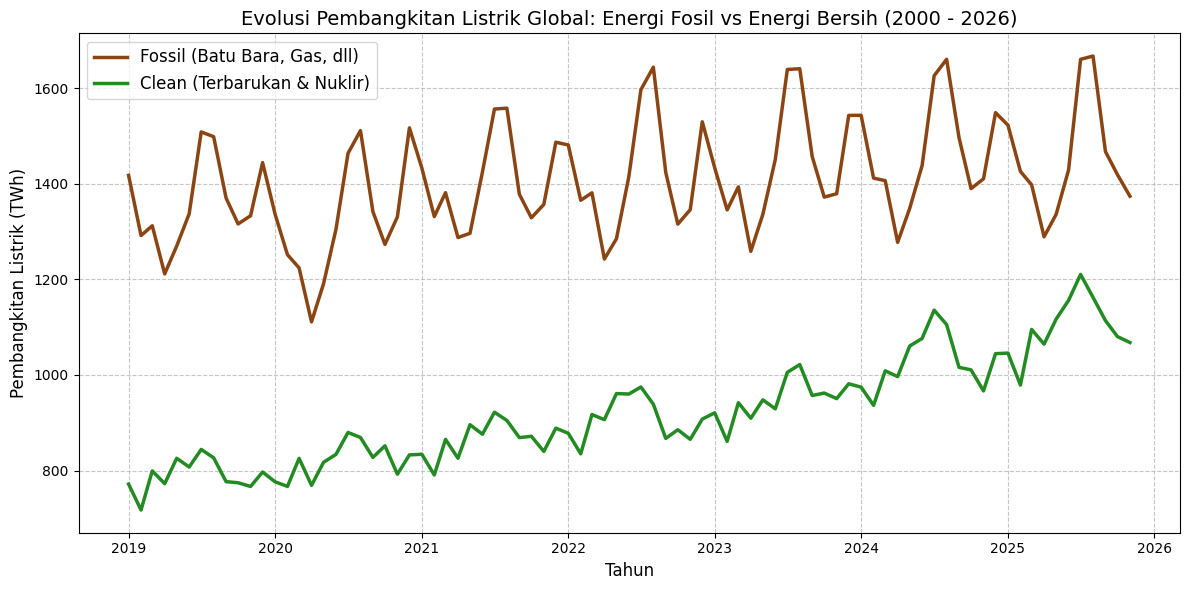

In [28]:
cond_area = df['Area'] == 'World'
cond_cat = df['Category'] == 'Electricity generation'
cond_sub = df['Subcategory'] == 'Aggregate fuel'
cond_var = df['Variable'].isin(['Fossil', 'Clean'])
cond_unit = df['Unit'] == 'TWh'

df_chart = df[cond_area & cond_cat & cond_sub & cond_var & cond_unit].copy()

df_pivot = df_chart.pivot_table(index='Date', columns='Variable', values='Value')

plt.figure(figsize=(12, 6))
plt.plot(df_pivot.index, df_pivot['Fossil'], label='Fossil (Batu Bara, Gas, dll)', color='saddlebrown', linewidth=2.5)
plt.plot(df_pivot.index, df_pivot['Clean'], label='Clean (Terbarukan & Nuklir)', color='forestgreen', linewidth=2.5)

plt.title('Evolusi Pembangkitan Listrik Global: Energi Fosil vs Energi Bersih (2000 - 2026)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Pembangkitan Listrik (TWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

print("Sampel Data Tren Global (TWh):")
print(df_pivot.dropna().iloc[[-12, -6, -1]])

Temuan: pembangkitan dari energi bersih (garis hijau) terlihat terus meningkat secara konsisten dari tahun ke tahun. Di sisi lain,  energi fosil memiliki pola yang sangat fluktuatif (naik-turun tajam, biasanya mengikuti siklus musim dingin/panas di mana permintaan listrik melonjak) namun secara tren jangka panjang, cenderung mendatar atau tidak secepat energi bersih.

Bar Chart untuk melihat Top 10 negara penghasil energi bersih terbesar. Menggunakan data dari tahun 2024 karena tahun ini adalah tahun penuh terakhir yang datanya sudah stabil dan minim nilai kosong:

Top 10 Negara (TWh):
Area
China                       3749.81
United States of America    1835.23
Brazil                       683.21
France                       495.71
Canada                       485.40
India                        461.74
Russian Federation (the)     428.41
Japan                        325.46
Germany                      276.10
South Korea                  242.34
Name: Value, dtype: float64


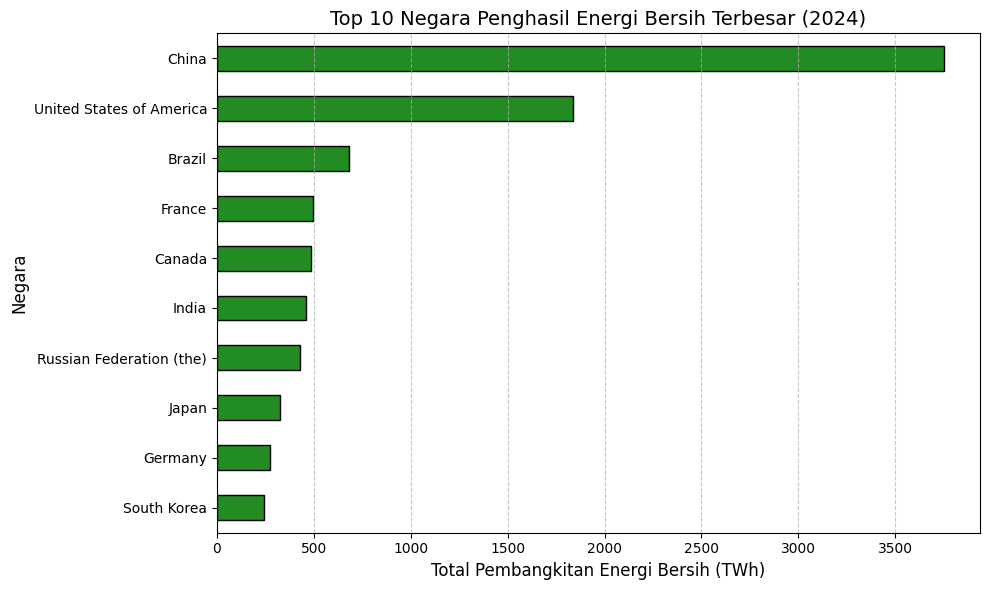

In [29]:
cond_area = df['Area type'] == 'Country or economy'
cond_cat = df['Category'] == 'Electricity generation'
cond_sub = df['Subcategory'] == 'Aggregate fuel'
cond_var = df['Variable'] == 'Clean'
cond_unit = df['Unit'] == 'TWh'
cond_year = df['Year'] == 2024

df_clean_2024 = df[cond_area & cond_cat & cond_sub & cond_var & cond_unit & cond_year].copy()

top10_clean = df_clean_2024.groupby('Area')['Value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10_clean.sort_values(ascending=True).plot(kind='barh', color='forestgreen', edgecolor='black')

plt.title('Top 10 Negara Penghasil Energi Bersih Terbesar (2024)', fontsize=14)
plt.xlabel('Total Pembangkitan Energi Bersih (TWh)', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

print("Top 10 Negara (TWh):")
print(top10_clean)

Catatan: jika mempertimbangkan ukuran negara dan jumlah penduduknya, angka absolut (TWh) ini belum tentu menceritakan keseluruhan cerita tentang seberapa "hijau" negara tersebut. Maka dari itu Persentase (%) adalah satuan yang jauh lebih adil untuk mengukur transisi energi. Satuan absolut (TWh) hanya menunjukkan siapa yang punya pabrik listrik paling banyak, tetapi persentase menunjukkan komposisi sesungguhnya dari jaring listrik suatu negara:

Top 10 Negara berdasarkan Persentase (%):
Area
Sweden         100.00
Uruguay         99.28
Norway          98.74
France          96.15
Switzerland     95.46
Finland         93.72
Kenya           93.24
Tajikistan      92.85
Brazil          91.26
Austria         89.85
Name: Value, dtype: float64


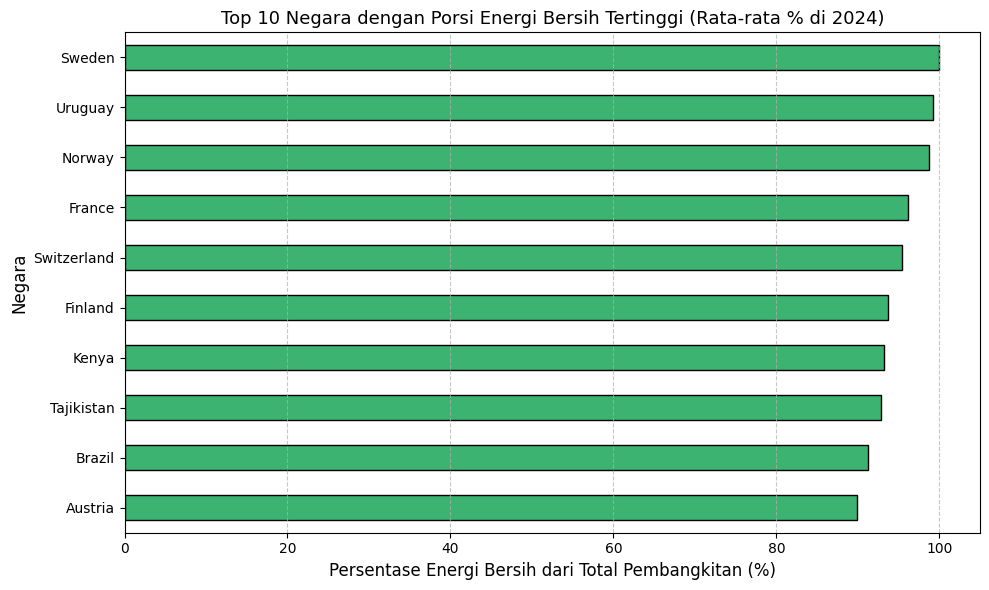

In [30]:
cond_area = df['Area type'] == 'Country or economy'
cond_var = df['Variable'] == 'Clean'
cond_unit = df['Unit'] == '%'
cond_year = df['Year'] == 2024

df_clean_pct = df[cond_area & cond_var & cond_unit & cond_year].copy()

top10_pct = df_clean_pct.groupby('Area')['Value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10_pct.sort_values(ascending=True).plot(kind='barh', color='mediumseagreen', edgecolor='black')

plt.title('Top 10 Negara dengan Porsi Energi Bersih Tertinggi (Rata-rata % di 2024)', fontsize=13)
plt.xlabel('Persentase Energi Bersih dari Total Pembangkitan (%)', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.xlim(0, 105)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

print("Top 10 Negara berdasarkan Persentase (%):")
print(top10_pct.round(2))

Temuan: negara-negara raksasa seperti China dan AS menghilang dari daftar karena total kebutuhan energi mereka sangat besar. Meski mereka menghasilkan energi bersih dalam jumlah masif (TWh tinggi), mereka masih sangat bergantung pada bahan bakar fosil untuk menopang sisa kebutuhan negaranya.

## **PREPROCESSING**

Membiarkan missing values pada kolom identitas wilayah karena baris tersebut secara valid mewakili data agregat kawasan/global yang tidak memiliki ISO code:

In [31]:
missing_iso = df[df['ISO 3 code'].isnull()]

area_type_counts = missing_iso['Area type'].value_counts().to_frame()
sample_areas = missing_iso['Area'].unique()

print("Area type untuk data yang ISO 3 code-nya kosong:")
print(area_type_counts)
print("\nContoh area:")
print(sample_areas)

Area type untuk data yang ISO 3 code-nya kosong:
           count
Area type       
Region     55795

Contoh area:
<StringArray>
[                      'ASEAN',                        'Asia',
                          'EU',                      'Europe',
                         'G20',                          'G7',
 'Latin America and Caribbean',               'North America',
                     'Oceania',                        'OECD',
                       'World']
Length: 11, dtype: str


### Convert DateTime

In [32]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['YearMonth'] = df['Date'].dt.strftime('%Y-%m')

result = df[['Date', 'Year', 'Month', 'Quarter', 'YearMonth']].head()
dtype_date = df['Date'].dtype

print("Hasil Ekstraksi Waktu:")
print(result)
print(f"\nTipe data 'Date' sekarang: {dtype_date}")

Hasil Ekstraksi Waktu:
        Date  Year  Month  Quarter YearMonth
0 2018-01-01  2018      1        1   2018-01
1 2018-01-01  2018      1        1   2018-01
2 2018-01-01  2018      1        1   2018-01
3 2018-01-01  2018      1        1   2018-01
4 2018-01-01  2018      1        1   2018-01

Tipe data 'Date' sekarang: datetime64[us]


### Handle Missing Value

Menghapus baris dengan nilai 'Value' kosong (NaN), karena jika diisi dengan 0 (imputasi) akan mendistorsi fakta bahwa tidak ada penggunaan/pembangkitan listrik, yang mana bisa saja disebabkan oleh keterlambatan pelaporan data:

In [33]:
initial_rows = len(df)

df_cleaned = df.dropna(subset=['Value']).copy()

final_rows = len(df_cleaned)
dropped_rows = initial_rows - final_rows

print(f"Baris awal: {initial_rows}")
print(f"Baris setelah di-drop: {final_rows}")
print(f"Total baris yang dihapus: {dropped_rows}")

Baris awal: 501483
Baris setelah di-drop: 498191
Total baris yang dihapus: 3292


### Filtering

Melakukan subsetting data spesifik pada area tipe negara dan subkategori total untuk mengisolasi metrik 'Total Pembangkitan Listrik', sehingga mencegah terjadinya double counting dari agregat kawasan maupun rincian per bahan bakar:

In [34]:
condition_area = df_cleaned['Area type'] == 'Country or economy'
condition_cat = df_cleaned['Category'] == 'Electricity generation'
condition_sub = df_cleaned['Subcategory'] == 'Total'

df_filtered = df_cleaned[condition_area & condition_cat & condition_sub].copy()

print(f"Jumlah baris sebelum filter: {len(df_cleaned)}")
print(f"Jumlah baris setelah filter untuk Total Pembangkitan Negara: {len(df_filtered)}")
print("\nContoh hasil filter:")
print(df_filtered[['Area', 'Date', 'Variable', 'Unit', 'Value']].head())

Jumlah baris sebelum filter: 498191
Jumlah baris setelah filter untuk Total Pembangkitan Negara: 10419

Contoh hasil filter:
          Area       Date          Variable Unit  Value
29   Argentina 2018-01-01  Total Generation  TWh  12.76
76   Argentina 2018-02-01  Total Generation  TWh  11.76
123  Argentina 2018-03-01  Total Generation  TWh  11.62
170  Argentina 2018-04-01  Total Generation  TWh  10.86
217  Argentina 2018-05-01  Total Generation  TWh  10.99


In [35]:
df_filtered.head()

,Area,ISO 3 code,Date,Area type,Continent,Ember region,EU,OECD,G20,G7,...,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change,Year,Month,Quarter,YearMonth
29,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,...,Total,Total Generation,TWh,12.76,NaN,NaN,2018,1,1,2018-01
76,Argentina,ARG,2018-02-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,...,Total,Total Generation,TWh,11.76,NaN,NaN,2018,2,1,2018-02
123,Argentina,ARG,2018-03-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,...,Total,Total Generation,TWh,11.62,NaN,NaN,2018,3,1,2018-03
170,Argentina,ARG,2018-04-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,...,Total,Total Generation,TWh,10.86,NaN,NaN,2018,4,2,2018-04
217,Argentina,ARG,2018-05-01,Country or economy,South America,Latin America and Caribbean,0.0,0.0,1.0,0.0,...,Total,Total Generation,TWh,10.99,NaN,NaN,2018,5,2,2018-05


In [36]:
cols_to_drop = [
    'Category', 'Subcategory', 'Variable', # Kolom konstan
    'EU', 'OECD', 'G20', 'G7', 'ASEAN',    # Org flags
    'YoY absolute change', 'YoY % change'  # Historical dengan banyak null
]

df_final = df_filtered.drop(columns=cols_to_drop)

print(f"Sisa kolom: {len(df_final.columns)}")
print("Daftar kolom final:")
print(df_final.columns.tolist())

Sisa kolom: 12
Daftar kolom final:
['Area', 'ISO 3 code', 'Date', 'Area type', 'Continent', 'Ember region', 'Unit', 'Value', 'Year', 'Month', 'Quarter', 'YearMonth']


In [37]:
df_final.head()

,Area,ISO 3 code,Date,Area type,Continent,Ember region,Unit,Value,Year,Month,Quarter,YearMonth
29,Argentina,ARG,2018-01-01,Country or economy,South America,Latin America and Caribbean,TWh,12.76,2018,1,1,2018-01
76,Argentina,ARG,2018-02-01,Country or economy,South America,Latin America and Caribbean,TWh,11.76,2018,2,1,2018-02
123,Argentina,ARG,2018-03-01,Country or economy,South America,Latin America and Caribbean,TWh,11.62,2018,3,1,2018-03
170,Argentina,ARG,2018-04-01,Country or economy,South America,Latin America and Caribbean,TWh,10.86,2018,4,2,2018-04
217,Argentina,ARG,2018-05-01,Country or economy,South America,Latin America and Caribbean,TWh,10.99,2018,5,2,2018-05
